<a href="https://colab.research.google.com/github/Aysha2004/INTERNSHIP/blob/main/S7_Internship_d2_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [4]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [7]:
df['Age_mean_imputed'] = df['Age'].fillna(df['Age'].mean())
df['Age_median_imputed'] = df['Age'].fillna(df['Age'].median())

df['Monthly_Salary_mean_imputed'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())
df['Monthly_Salary_median_imputed'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].median())

df['Department_mode_imputed'] = df['Department'].fillna(df['Department'].mode()[0])
df['Education_mode_imputed'] = df['Education'].fillna(df['Education'].mode()[0])
df['City_mode_imputed'] = df['City'].fillna(df['City'].mode()[0])

In [8]:
df[['Age','Age_mean_imputed','Age_median_imputed']]

,Age,Age_mean_imputed,Age_median_imputed
0,59.0,59.0,59.0
1,49.0,49.0,49.0
2,35.0,35.0,35.0
3,28.0,28.0,28.0
4,41.0,41.0,41.0
...,...,...,...
95,54.0,54.0,54.0
96,53.0,53.0,53.0
97,43.0,43.0,43.0
98,44.0,44.0,44.0


In [9]:
df[['Monthly_Salary','Monthly_Salary_mean_imputed','Monthly_Salary_median_imputed']]

,Monthly_Salary,Monthly_Salary_mean_imputed,Monthly_Salary_median_imputed
0,52350.0,52350.0,52350.0
1,118008.0,118008.0,118008.0
2,119297.0,119297.0,119297.0
3,50351.0,50351.0,50351.0
4,113668.0,113668.0,113668.0
...,...,...,...
95,48625.0,48625.0,48625.0
96,107873.0,107873.0,107873.0
97,97592.0,97592.0,97592.0
98,102052.0,102052.0,102052.0


In [10]:
df[['Department','Department_mode_imputed']]

,Department,Department_mode_imputed
0,HR,HR
1,Marketing,Marketing
2,HR,HR
3,HR,HR
4,IT,IT
...,...,...
95,HR,HR
96,Marketing,Marketing
97,NaN,HR
98,Marketing,Marketing


In [11]:
df[['Education','Education_mode_imputed']]

,Education,Education_mode_imputed
0,Masters,Masters
1,Bachelors,Bachelors
2,NaN,Masters
3,PhD,PhD
4,Bachelors,Bachelors
...,...,...
95,Masters,Masters
96,Masters,Masters
97,PhD,PhD
98,PhD,PhD


In [12]:
df[['City','City_mode_imputed']]

,City,City_mode_imputed
0,Calicut,Calicut
1,Chennai,Chennai
2,Kochi,Kochi
3,Trivandrum,Trivandrum
4,Trivandrum,Trivandrum
...,...,...
95,Chennai,Chennai
96,Trivandrum,Trivandrum
97,Chennai,Chennai
98,Calicut,Calicut


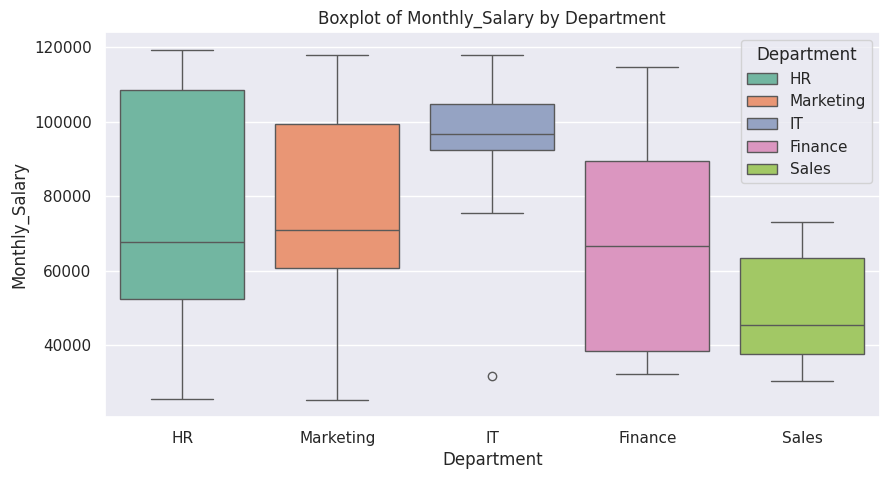

In [14]:
sns.set(style = 'darkgrid')
plt.figure(figsize = (10,5))

sns.boxplot(data = df, x = 'Department', y = 'Monthly_Salary', hue = 'Department', palette = 'Set2')
plt.title('Boxplot of Monthly_Salary by Department')
plt.xlabel('Department')
plt.ylabel('Monthly_Salary')
plt.show()

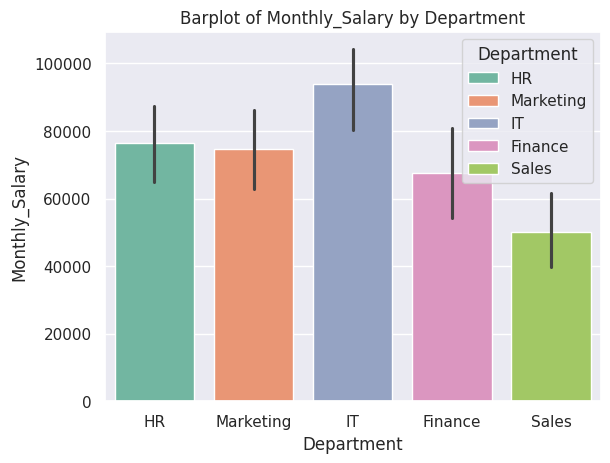

In [15]:
sns.barplot(data = df, x = 'Department', y = 'Monthly_Salary', hue = 'Department', palette = 'Set2')
plt.title('Barplot of Monthly_Salary by Department')
plt.xlabel('Department')
plt.ylabel('Monthly_Salary')
plt.show()

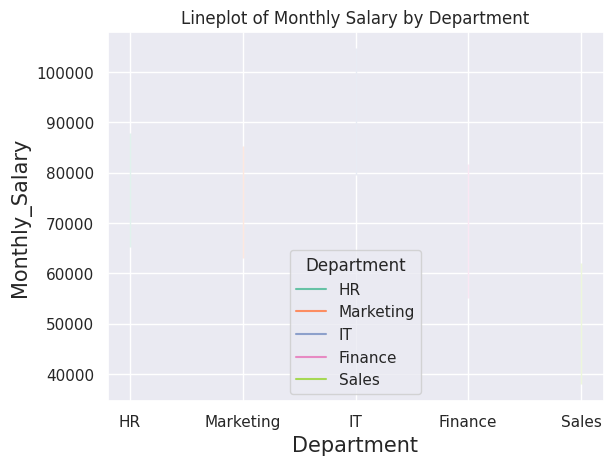

In [20]:
sns.lineplot(data = df, x = 'Department', y = 'Monthly_Salary', hue = 'Department', palette = 'Set2')
plt.title('Lineplot of Monthly Salary by Department')
plt.xlabel('Department',fontsize = 15)
plt.ylabel('Monthly_Salary', fontsize = 15)
plt.show()

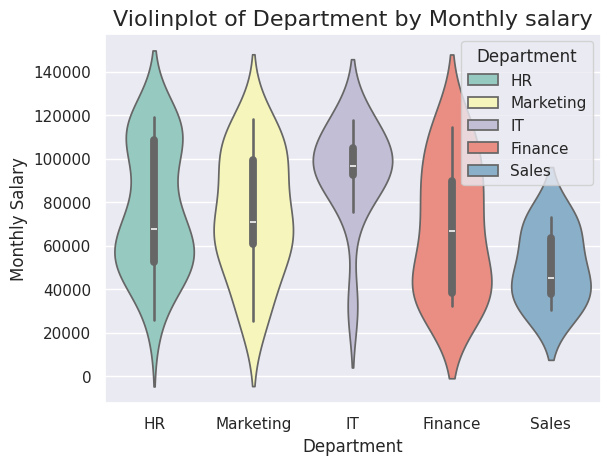

In [19]:
sns.violinplot(data=df,x='Department',y='Monthly_Salary',hue='Department',palette='Set3')
plt.title('Violinplot of Department by Monthly salary',fontsize=16)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Monthly Salary',fontsize=12)
plt.show()

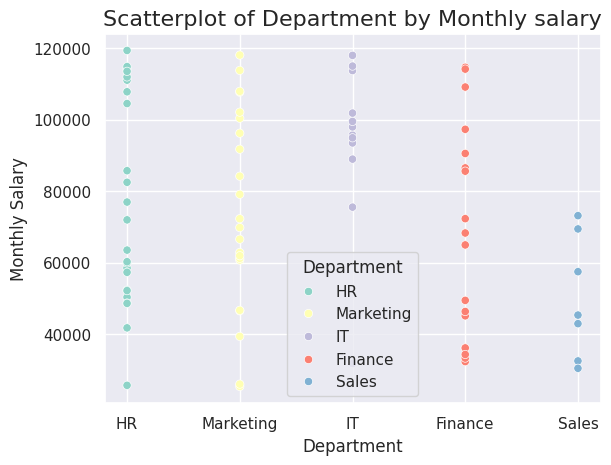

In [21]:
sns.scatterplot(data=df,x='Department',y='Monthly_Salary',hue='Department',palette='Set3')
plt.title('Scatterplot of Department by Monthly salary',fontsize=16)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Monthly Salary',fontsize=12)
plt.show()

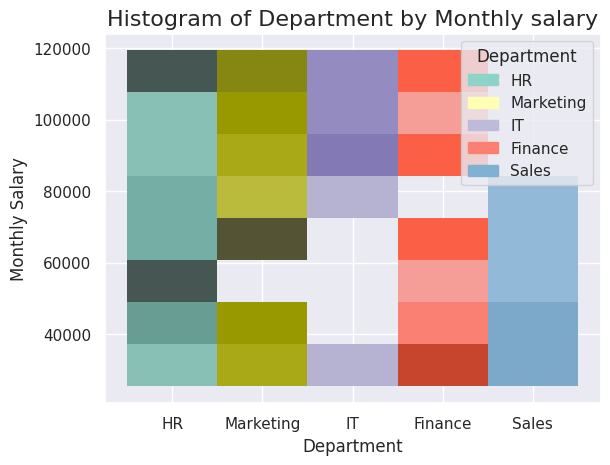

In [25]:
sns.histplot(data=df,x='Department',y='Monthly_Salary',hue='Department',palette='Set3')
plt.title('Histogram of Department by Monthly salary',fontsize=16)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Monthly Salary',fontsize=12)
plt.show()sns.violinplot(data=df,x='Department',y='Monthly_Salary',palette='Set3')
plt.title('Violinplot of Department by Monthly salary',fontsize=16)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Monthly Salary',fontsize=12)
plt.show()

In [29]:
encoded_data = df.copy()
label_encoder = LabelEncoder()
encoded_data['Gender_encoded'] = label_encoder.fit_transform(encoded_data['Gender'])

In [31]:
one_hot_encoded_data = pd.get_dummies(df, columns = ['Department'],prefix='Department')
encoded_data = pd.concat([encoded_data,one_hot_encoded_data],axis=1)

In [46]:
print(type(encoded_data['Performance_Rating']))
print(encoded_data['Performance_Rating'].shape)

<class 'pandas.core.frame.DataFrame'>
(100, 2)


In [47]:
Performance_Rating_mapping = {'Fair':1,'Poor':2,'Good':3,'Very_Good':4,'Excellent':5}
encoded_data['Performance_Rating_encoded'] = encoded_data['Performance_Rating'].iloc[:,1].map(Performance_Rating_mapping)

In [49]:
print(encoded_data.columns.tolist())

['Employee_ID', 'Age', 'Gender', 'Department', 'Education', 'Experience_Years', 'Monthly_Salary', 'Performance_Rating', 'City', 'Attrition', 'Age_mean_imputed', 'Age_median_imputed', 'Monthly_Salary_mean_imputed', 'Monthly_Salary_median_imputed', 'Department_mode_imputed', 'Education_mode_imputed', 'City_mode_imputed', 'Gender_encoded', 'Employee_ID', 'Age', 'Gender', 'Education', 'Experience_Years', 'Monthly_Salary', 'Performance_Rating', 'City', 'Attrition', 'Age_mean_imputed', 'Age_median_imputed', 'Monthly_Salary_mean_imputed', 'Monthly_Salary_median_imputed', 'Department_mode_imputed', 'Education_mode_imputed', 'City_mode_imputed', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Performance_Rating_encoded']


In [51]:

print(encoded_data[['Gender','Gender_encoded','Department','Department_HR','Department_Marketing','Department_IT','Department_Finance',"Department_Sales",'Performance_Rating','Performance_Rating_encoded']].head())


   Gender  Gender  Gender_encoded Department  Department_HR  \
0    Male    Male               1         HR           True   
1  Female  Female               0  Marketing          False   
2  Female  Female               0         HR           True   
3  Female  Female               0         HR           True   
4    Male    Male               1         IT          False   

   Department_Marketing  Department_IT  Department_Finance  Department_Sales  \
0                 False          False               False             False   
1                  True          False               False             False   
2                 False          False               False             False   
3                 False          False               False             False   
4                 False           True               False             False   

   Performance_Rating  Performance_Rating  Performance_Rating_encoded  
0                   5                   5                         Na

In [54]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [56]:
numerical_columns=['Age','Monthly_Salary']

In [57]:
prepro_data=df.copy()minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [59]:
prepro_data.dropna(subset=numerical_columns, inplace=True)

In [65]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

In [66]:
prepro_data['Age_MinMax']=minmax_scaler.fit_transform(prepro_data[['Age']])
prepro_data['Monthly_Salary_MinMax']=minmax_scaler.fit_transform(prepro_data[['Monthly_Salary']])

In [67]:
prepro_data['Age_Standard']=standard_scaler.fit_transform(prepro_data[['Age']])
prepro_data['Monthly_Salary_Standard']=standard_scaler.fit_transform(prepro_data[['Monthly_Salary']])


In [68]:
prepro_data[['Age','Age_MinMax','Age_Standard','Monthly_Salary','Monthly_Salary_MinMax','Monthly_Salary_Standard']]


,Age,Age_MinMax,Age_Standard,Monthly_Salary,Monthly_Salary_MinMax,Monthly_Salary_Standard
0,59.0,1.000000,1.811984,52350.0,0.286925,-0.802101
1,49.0,0.736842,0.889855,118008.0,0.986270,1.557801
2,35.0,0.368421,-0.401126,119297.0,1.000000,1.604131
3,28.0,0.184211,-1.046617,50351.0,0.265633,-0.873950
4,41.0,0.526316,0.152151,113668.0,0.940044,1.401811
...,...,...,...,...,...,...
95,54.0,0.868421,1.350919,48625.0,0.247249,-0.935986
96,53.0,0.842105,1.258706,107873.0,0.878319,1.193525
97,43.0,0.578947,0.336577,97592.0,0.768813,0.824002
98,44.0,0.605263,0.428790,102052.0,0.816318,0.984305
